In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('Pokemon.csv')
data = data.set_index('#')

In [2]:
data.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## EDA

In [3]:
data2 = data.copy(deep=True)
del data2['Legendary']
del data2['Generation']
del data2['Total']

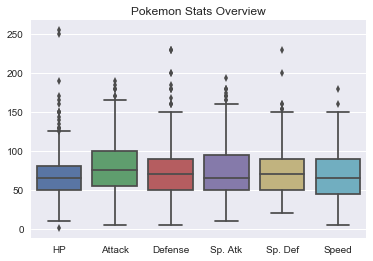

In [4]:
%matplotlib inline
sns.boxplot(data=data2)
plt.title("Pokemon Stats Overview")

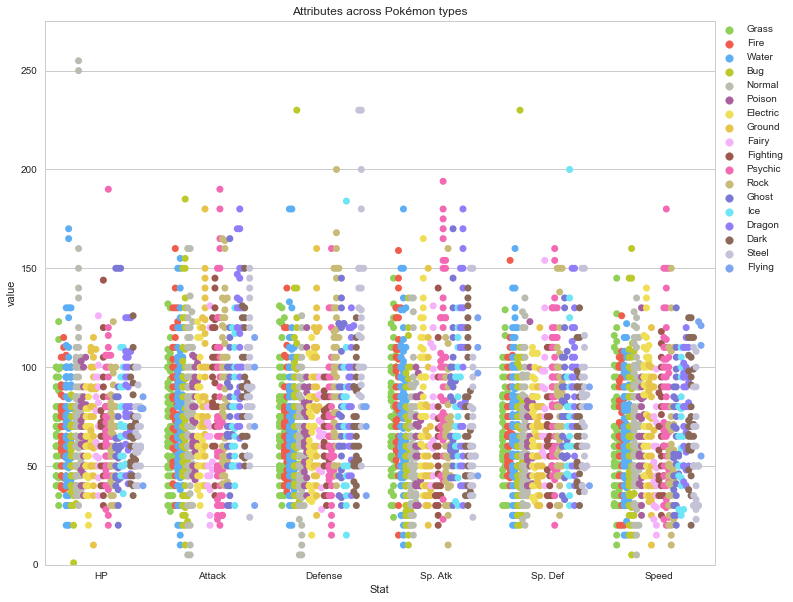

In [5]:
# Many thanks to: https://www.kaggle.com/ndrewgele/visualizing-pok-mon-stats-with-seaborn for this graph.
pkmn = pd.melt(data2, id_vars=["Name", "Type 1", "Type 2"], var_name="Stat")
sns.set_style("whitegrid")
with sns.color_palette([
    "#8ED752", "#F95643", "#53AFFE", "#C3D221", "#BBBDAF",
    "#AD5CA2", "#F8E64E", "#F0CA42", "#F9AEFE", "#A35449",
    "#FB61B4", "#CDBD72", "#7673DA", "#66EBFF", "#8B76FF",
    "#8E6856", "#C3C1D7", "#75A4F9"], n_colors=18, desat=.9):
    plt.figure(figsize=(12,10))
    plt.ylim(0, 275)
    sns.swarmplot(x="Stat", y="value", data=pkmn, hue="Type 1", split=True, size=7)
    plt.title('Attributes across Pokémon types')
    plt.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0.);

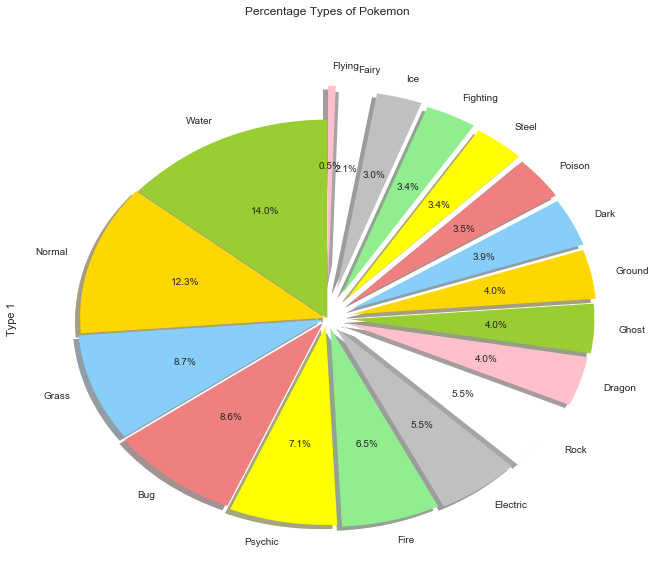

In [6]:
types = pkmn['Type 1']

colors = [
    'yellowgreen',
    'gold',
    'lightskyblue',
    'lightcoral',
    'yellow',
    'lightgreen',
    'silver',
    'white',
    'pink'
]

explode = np.arange(len(types.unique())) * 0.01
plt.figure(figsize=(20,30))
types.value_counts().plot.pie(
    explode=explode,
    colors=colors,
    title="Types of Pokemon",
    autopct='%1.1f%%',
    shadow=True,
    startangle=90,
    figsize=(9,8)
)
plt.title("Percentage Types of Pokemon", y=1.1)
plt.tight_layout()

## Feature Engineering 

In [7]:
# Not interested in type 2.
del data['Type 2']
del data['Total']

# Create a binary response variable for each type and generation.
type1 = data.pop('Type 1')
response_values = pd.get_dummies(type1)
dummies_list = []
for x in response_values:
    word = 'Type_1_' + x
    dummies_list.append(word)
response_values.columns = dummies_list

gen = data.pop('Generation')
dummies_2 = pd.get_dummies(gen)
dummies1list = []
for x in dummies_2:
    word = 'Generation_' + str(x)
    dummies1list.append(word)
dummies_2.columns = dummies1list

In [8]:
# Finalising the dataset.
data = pd.concat([data, dummies_2], axis=1)

# Set the base case as a normal pokemon from the 6th generation.
del response_values['Type_1_Normal']
del data['Generation_6']
del data['Name']
#Converts the boolean column into a column of 0's and 1's.
data.Legendary = data.Legendary.astype(int)

## Modelling

In [9]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

# Creating training and test set with 80-20 split.
X_train, X_test, y_train, y_test = train_test_split(data, response_values, test_size = 0.2, random_state = 100)

# Normalise the features for some models
norm_train = preprocessing.normalize(X_train)
norm_test = preprocessing.normalize(X_test)

Models to try out are:

* Logistic Regression
* Naive Bayes
* Decision Trees
* Random Forest
* Adaptive Boosting
* Gradient Boosting

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score

def predictingModel(model):
    '''Computes accuracy and confusion matrices for models without normalised features.'''
    accuracy = []
    confusion_matrices = []
    for y_type in y_train:
        model.fit(X_train, (y_train[y_type]))
        pred = model.predict(X_test)
        confusion_matrices.append(confusion_matrix(y_test[y_type],pred))
        accuracy.append(accuracy_score(y_test[y_type],pred))
    return accuracy, confusion_matrices

In [11]:
def predictingModel2(model):
    '''Computes accuracy and confusion matrices for models with normalised features.'''
    accuracy = []
    confusion_matrices = []
    for y_type in y_train:
        model.fit(norm_train, (y_train[y_type]))
        pred = model.predict(norm_test)
        confusion_matrices.append(confusion_matrix(y_test[y_type],pred))
        accuracy.append(accuracy_score(y_test[y_type],pred))
    return accuracy, confusion_matrices

#### Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

# Logistic regression object.
Logistic_reg = LogisticRegression(random_state=15)
LG_A, LG_C = predictingModel(Logistic_reg)

#### Naive Bayes

In [14]:
from sklearn.naive_bayes import GaussianNB

# Creates Naive Bayes object.
naive_bayes = GaussianNB()
# Making our final predictions on test set.
NB_A, NB_C = predictingModel2(naive_bayes)